<a href="https://colab.research.google.com/github/irungus/tree-species-ml-pipeline/blob/main/notebooks/01_data_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.0/478.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 107.3 MB/s eta 0:00:00


In [1]:
import pandas as pd # load and preprocess data
import os #manage file paths and directories.
import requests # sending HTTP requests to interact with web APIs or download content from the internet.
import io #Provides tools for working with I/O streams.
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns# Data visualization
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import ee
import ee
import time
from tqdm import tqdm

In [2]:
ee.Authenticate()
ee.Initialize(project='agfkenya')

In [3]:
url = "https://raw.githubusercontent.com/irungus/tree-species-ml-pipeline/main/data/raw/Data.csv"
df = pd.read_csv(url)

print(df.head())
print(f"Total points: {len(df)}")

# Working dataframe
feature_df = df.copy()

    uid     species  latitude  longitude
0  6042      Acacia -4.537429  39.139728
1  5988  Eucalyptus -4.522492  39.183680
2  5985  Eucalyptus -4.522487  39.183677
3  5982  Eucalyptus -4.522480  39.183657
4  5932  Eucalyptus -4.472281  39.189929
Total points: 3071


# Helper Functions

In [4]:
def extract_values(image, point):
    try:
        values = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=30,
            bestEffort=True
        )
        return values.getInfo()
    except:
        return {}

## FEATURE EXTRACTION (GEE + Python)

We’ll extract:

### 🌱 Vegetation Indices (Sentinel-2)
- NDVI  
- EVI  
- SAVI  

### 📡 SAR Features (Sentinel-1)
- VV  
- VH  
- VV/VH ratio  

### 🌡 Climate
- Temperature (mean)  
- Precipitation (mean)  

### ⛰ Terrain
- Elevation  
- Slope  

# Vegetation Indices

In [5]:
veg_results = []

for i, row in tqdm(df.iterrows(), total=len(df), desc="Vegetation"):
    point = ee.Geometry.Point([row["longitude"], row["latitude"]])

    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(point)
        .filterDate("2022-01-01", "2022-12-31")
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .select(["B2", "B4", "B8"])
        .median()
    )

    ndvi = s2.normalizedDifference(["B8", "B4"]).rename("NDVI")

    evi = s2.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {
            "NIR": s2.select("B8"),
            "RED": s2.select("B4"),
            "BLUE": s2.select("B2"),
        },
    ).rename("EVI")

    savi = s2.expression(
        "((NIR - RED) / (NIR + RED + 0.5)) * 1.5",
        {
            "NIR": s2.select("B8"),
            "RED": s2.select("B4"),
        },
    ).rename("SAVI")

    img = ee.Image.cat([ndvi, evi, savi])

    vals = extract_values(img, point)
    veg_results.append(vals)

    time.sleep(0.1)  # avoid API throttling

veg_df = pd.DataFrame(veg_results)
feature_df = pd.concat([feature_df, veg_df], axis=1)

feature_df.to_csv("vegetation_done.csv", index=False)
print("✅ Vegetation complete")

Vegetation: 100%|██████████| 3071/3071 [47:48<00:00,  1.07it/s]

✅ Vegetation complete


# SAR Features

In [6]:
sar_results = []

for i, row in tqdm(df.iterrows(), total=len(df), desc="SAR"):
    point = ee.Geometry.Point([row["longitude"], row["latitude"]])

    s1 = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(point)
        .filterDate("2022-01-01", "2022-12-31")
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
        .median()
    )

    ratio = s1.select("VV").divide(s1.select("VH")).rename("VV_VH_ratio")

    img = ee.Image.cat([
        s1.select("VV"),
        s1.select("VH"),
        ratio
    ])

    vals = extract_values(img, point)
    sar_results.append(vals)

    time.sleep(0.1)

sar_df = pd.DataFrame(sar_results)
feature_df = pd.concat([feature_df, sar_df], axis=1)

feature_df.to_csv("sar_done.csv", index=False)
print("✅ SAR complete")

SAR: 100%|██████████| 3071/3071 [21:16<00:00,  2.41it/s]

✅ SAR complete


# Terrain Features

In [7]:
terrain_results = []

dem = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(dem)

terrain_img = ee.Image.cat([
    dem.rename("elevation"),
    slope.rename("slope")
])

for i, row in tqdm(df.iterrows(), total=len(df), desc="Terrain"):
    point = ee.Geometry.Point([row["longitude"], row["latitude"]])

    vals = extract_values(terrain_img, point)
    terrain_results.append(vals)

terrain_df = pd.DataFrame(terrain_results)
feature_df = pd.concat([feature_df, terrain_df], axis=1)

feature_df.to_csv("terrain_done.csv", index=False)
print("✅ Terrain complete")

Terrain: 100%|██████████| 3071/3071 [05:17<00:00,  9.66it/s]

✅ Terrain complete


# Climate Features

In [8]:
climate_results = []

for i, row in tqdm(df.iterrows(), total=len(df), desc="Climate"):
    point = ee.Geometry.Point([row["longitude"], row["latitude"]])

    climate = (
        ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY")
        .filterBounds(point)
        .filterDate("2022-01-01", "2022-12-31")
        .mean()
    )

    vals = extract_values(climate, point)
    climate_results.append(vals)

    time.sleep(0.1)

climate_df = pd.DataFrame(climate_results)
feature_df = pd.concat([feature_df, climate_df], axis=1)

feature_df.to_csv("final_features.csv", index=False)
print("✅ Climate complete")

Climate:   0%|          | 0/3071 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for ECMWF/ERA5_LAND/MONTHLY! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY

  warnings.warn(warning, category=DeprecationWarning)
Climate: 100%|██████████| 3071/3071 [26:34<00:00,  1.93it/s]


✅ Climate complete


In [20]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.6 MB/s eta 0:00:00


In [22]:
import ipywidgets as widgets
from IPython.display import display

In [9]:
if os.path.exists("data/processed/vegetation.csv"):
    feature_df = pd.read_csv("data/processed/vegetation.csv")

In [23]:
url = "https://raw.githubusercontent.com/irungus/tree-species-ml-pipeline/main/data/raw/final_features.csv"
df = pd.read_csv(url)

print(df.head())
print(f"Total points: {len(df)}")

    uid     species  latitude  longitude       EVI      NDVI      SAVI  \
0  6042      Acacia -4.537429  39.139728  0.476082  0.251262  0.376848   
1  5988  Eucalyptus -4.522492  39.183680  0.711032  0.334040  0.501006   
2  5985  Eucalyptus -4.522487  39.183677  0.711032  0.334040  0.501006   
3  5982  Eucalyptus -4.522480  39.183657  0.711032  0.334040  0.501006   
4  5932  Eucalyptus -4.472281  39.189929  1.502694  0.298845  0.448226   

          VH         VV  VV_VH_ratio  ...  temperature_2m  \
0 -18.147271 -12.876735     0.709569  ...      299.024417   
1 -16.980324 -12.548029     0.738975  ...      299.116702   
2 -16.980324 -12.548029     0.738975  ...      299.116702   
3 -16.980324 -12.548029     0.738975  ...      299.116702   
4 -14.763931  -6.612564     0.447886  ...      299.116702   

   temperature_of_snow_layer  total_evaporation  total_precipitation  \
0                 273.160174          -0.001593             0.001282   
1                 273.160174          -0.001

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 62 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   uid                                                    3071 non-null   int64  
 1   species                                                3071 non-null   object 
 2   latitude                                               3071 non-null   float64
 3   longitude                                              3071 non-null   float64
 4   EVI                                                    3071 non-null   float64
 5   NDVI                                                   3071 non-null   float64
 6   SAVI                                                   3071 non-null   float64
 7   VH                                                     3071 non-null   float64
 8   VV                                              

In [25]:
df.describe()

,uid,latitude,longitude,EVI,NDVI,SAVI,VH,VV,VV_VH_ratio,elevation,...,temperature_2m,temperature_of_snow_layer,total_evaporation,total_precipitation,u_component_of_wind_10m,v_component_of_wind_10m,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4
count,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,...,3071.000000,3.071000e+03,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000,3071.000000
mean,3267.883751,-0.870953,36.415453,1.402616,0.569061,0.853467,-16.085551,-9.697875,0.594858,1488.649951,...,292.665048,2.731602e+02,-0.002196,0.002371,-0.694852,0.379305,0.306099,0.305706,0.296553,0.328615
std,2094.865038,1.179407,1.486559,0.672081,0.183947,0.275879,2.356548,2.475949,0.092074,485.640506,...,2.929837,9.721808e-12,0.000884,0.001490,0.535626,0.650431,0.091781,0.091792,0.093488,0.091720
min,0.000000,-4.537429,34.022104,0.154059,0.093726,0.140577,-25.810376,-19.447369,-0.315703,6.000000,...,287.642092,2.731602e+02,-0.003968,0.000293,-2.060092,-0.811261,0.054298,0.055951,0.059551,0.060268
25%,1569.500000,-1.058631,34.832796,0.928706,0.448583,0.672780,-17.250845,-11.240435,0.547179,1283.000000,...,290.507164,2.731602e+02,-0.002925,0.001111,-1.095249,-0.003278,0.228027,0.218405,0.203773,0.253312
50%,3111.000000,-0.563253,36.939160,1.444257,0.608397,0.912421,-15.773074,-9.629012,0.607045,1519.000000,...,292.850426,2.731602e+02,-0.002347,0.002121,-0.614739,0.243019,0.323989,0.328364,0.324319,0.343913
75%,4699.500000,-0.080068,37.467955,1.849837,0.702549,1.053674,-14.547085,-8.047024,0.652697,1835.000000,...,294.269452,2.731602e+02,-0.001373,0.003256,-0.426670,0.608172,0.380712,0.373432,0.362208,0.402964
max,7102.000000,1.215551,39.731914,9.861996,0.872818,1.309085,-5.851321,1.847281,0.861321,2478.000000,...,300.635582,2.731602e+02,-0.000371,0.007800,0.594326,2.905332,0.461399,0.467875,0.469771,0.494804


In [18]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
uid,0.0
species,0.0
latitude,0.0
longitude,0.0
EVI,0.0
...,...
v_component_of_wind_10m,0.0
volumetric_soil_water_layer_1,0.0
volumetric_soil_water_layer_2,0.0
volumetric_soil_water_layer_3,0.0


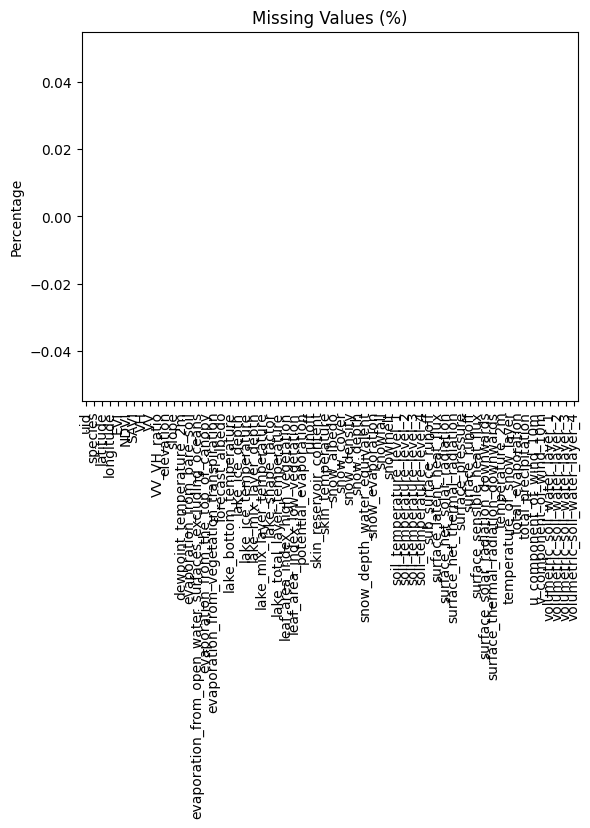

In [19]:
import matplotlib.pyplot as plt

missing_percent.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values (%)")
plt.ylabel("Percentage")
plt.show()